In [31]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# set style and palette for seaborn
sns.set_style("whitegrid")
sns.set_palette("Greens")

In [33]:
# read the dataset
df = pd.read_csv("../data/transactions.csv")

df.head(2)

,Transaction ID,Timestamp,Sender Name,Sender UPI ID,Receiver Name,Receiver UPI ID,Amount (INR),Status
0,4d3db980-46cd-4158-a812-dcb77055d0d2,2024-06-22 04:06:38,Tiya Mall,4161803452@okaxis,Mohanlal Golla,7776849307@okybl,3907.34,FAILED
1,099ee548-2fc1-4811-bf92-559c467ca792,2024-06-19 06:04:49,Mohanlal Bakshi,8908837379@okaxis,Mehul Sankaran,7683454560@okaxis,8404.55,SUCCESS


In [34]:
# Dataset Overview
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1000, 8)

Column Names:
Index(['Transaction ID', 'Timestamp', 'Sender Name', 'Sender UPI ID',
       'Receiver Name', 'Receiver UPI ID', 'Amount (INR)', 'Status'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction ID   1000 non-null   str    
 1   Timestamp        1000 non-null   str    
 2   Sender Name      1000 non-null   str    
 3   Sender UPI ID    1000 non-null   str    
 4   Receiver Name    1000 non-null   str    
 5   Receiver UPI ID  1000 non-null   str    
 6   Amount (INR)     1000 non-null   float64
 7   Status           1000 non-null   str    
dtypes: float64(1), str(7)
memory usage: 62.6 KB

Missing Values:
Transaction ID     0
Timestamp          0
Sender Name        0
Sender UPI ID      0
Receiver Name      0
Receiver UPI ID    0
Amount (INR)       0
Status             

C:\Users\DELL\AppData\Local\Temp\ipykernel_8036\1256764576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Status", data=df, palette="Greens")


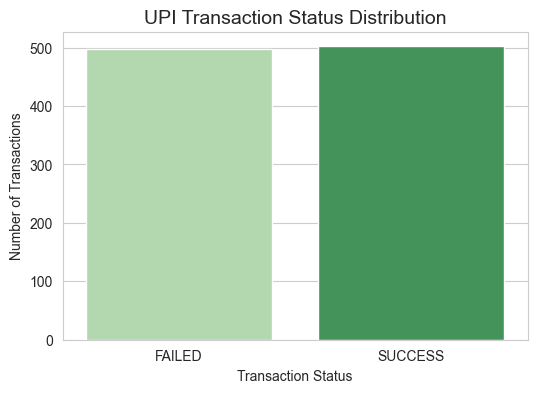

In [35]:
# Visualize Transaction Status Distribution
plt.figure(figsize=(6,4))

sns.countplot(x="Status", data=df, palette="Greens")

plt.title("UPI Transaction Status Distribution", fontsize=14)
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
plt.savefig("../plots/status_distribution.png")

plt.show()

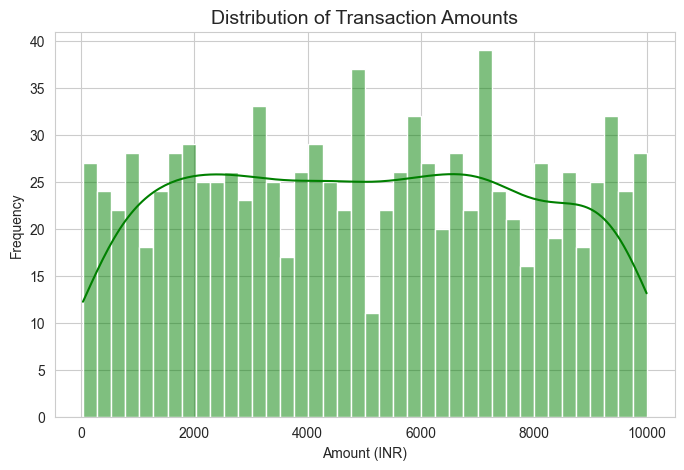

In [36]:
# visualize Transaction Amount Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Amount (INR)"], bins=40, kde=True, color="green")

plt.title("Distribution of Transaction Amounts", fontsize=14)
plt.xlabel("Amount (INR)")
plt.ylabel("Frequency")
plt.savefig("../plots/amount_distribution.png")

plt.show()

In [37]:
# Extracting Hour and Day of Week from Timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

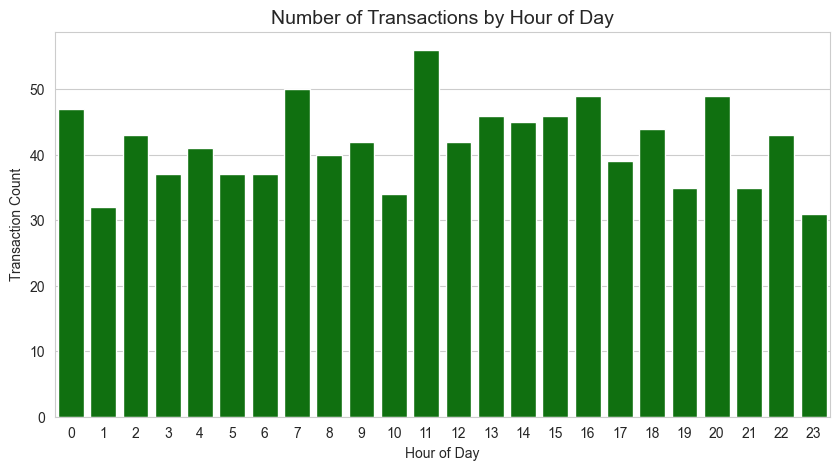

In [38]:
# Visualize Transactions by Hour of Day
plt.figure(figsize=(10,5))

sns.countplot(x="Hour", data=df, color="green")

plt.title("Number of Transactions by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.savefig("../plots/hour_distribution.png")

plt.show()

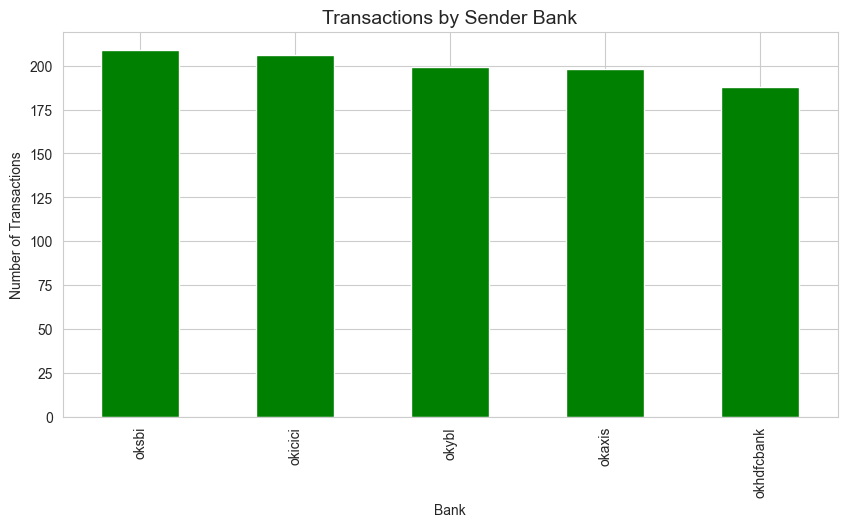

In [39]:
# Extract Sender Bank from UPI ID
df["Sender_Bank"] = df["Sender UPI ID"].apply(lambda x: x.split("@")[1])

plt.figure(figsize=(10,5))

df["Sender_Bank"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Transactions by Sender Bank", fontsize=14)
plt.xlabel("Bank")
plt.ylabel("Number of Transactions")
plt.savefig("../plots/sender_bank.png")

plt.show()

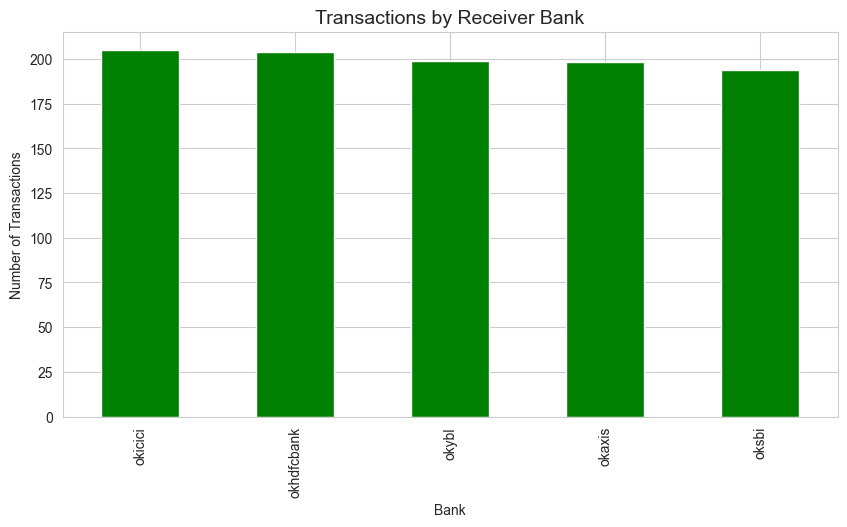

In [40]:
# Extract Receiver Bank from UPI ID
df["Receiver_Bank"] = df["Receiver UPI ID"].apply(lambda x: x.split("@")[1])

plt.figure(figsize=(10,5))

df["Receiver_Bank"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Transactions by Receiver Bank", fontsize=14)
plt.xlabel("Bank")
plt.ylabel("Number of Transactions")
plt.savefig("../plots/receiver_bank.png")

plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8036\60275152.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


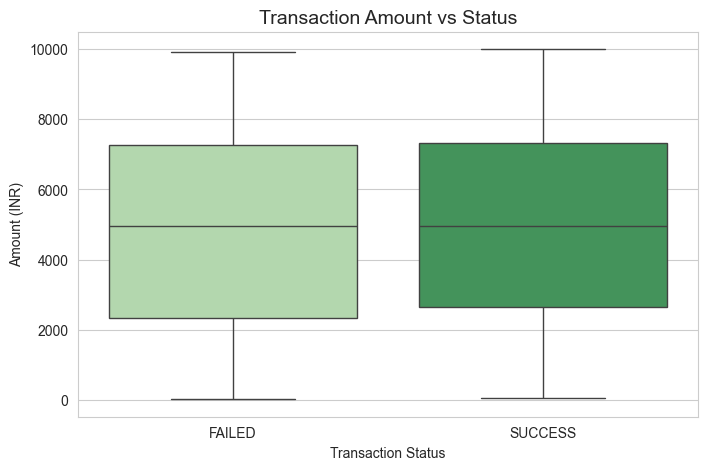

In [41]:
# Visualize Transaction Amount vs Status
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Status",
    y="Amount (INR)",
    data=df,
    palette="Greens"
)

plt.title("Transaction Amount vs Status", fontsize=14)
plt.xlabel("Transaction Status")
plt.ylabel("Amount (INR)")
plt.savefig("../plots/transaction_vs_status.png")

plt.show()

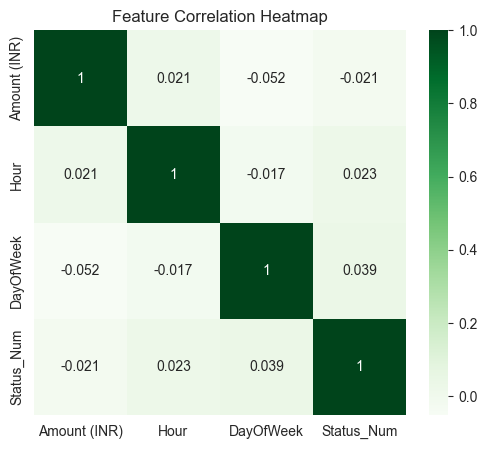

In [42]:
# Correlation Heatmap
df["Status_Num"] = df["Status"].map({
    "SUCCESS":0,
    "FAILED":1
})

plt.figure(figsize=(6,5))

sns.heatmap(
    df[["Amount (INR)", "Hour", "DayOfWeek", "Status_Num"]].corr(),
    annot=True,
    cmap="Greens"
)

plt.title("Feature Correlation Heatmap")
plt.savefig("../plots/correlation_heatmap.png")

plt.show()